In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## Task 2 — API Exploration

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 40.41,
    "longitude": 49.87,
    "start_date": "2025-04-19",
    "end_date": "2026-04-19",
    "daily": ["temperature_2m_max", "temperature_2m_min", "rain_sum", "windspeed_10m_max"],
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

print("API Response Structure keys:", data.keys())
print("\nDaily Units:", data['daily_units'])

df_baku = pd.DataFrame(data['daily'])
df_baku['time'] = pd.to_datetime(df_baku['time'])

API Response Structure keys: dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])

Daily Units: {'time': 'iso8601', 'temperature_2m_max': '°C', 'temperature_2m_min': '°C', 'rain_sum': 'mm', 'windspeed_10m_max': 'km/h'}


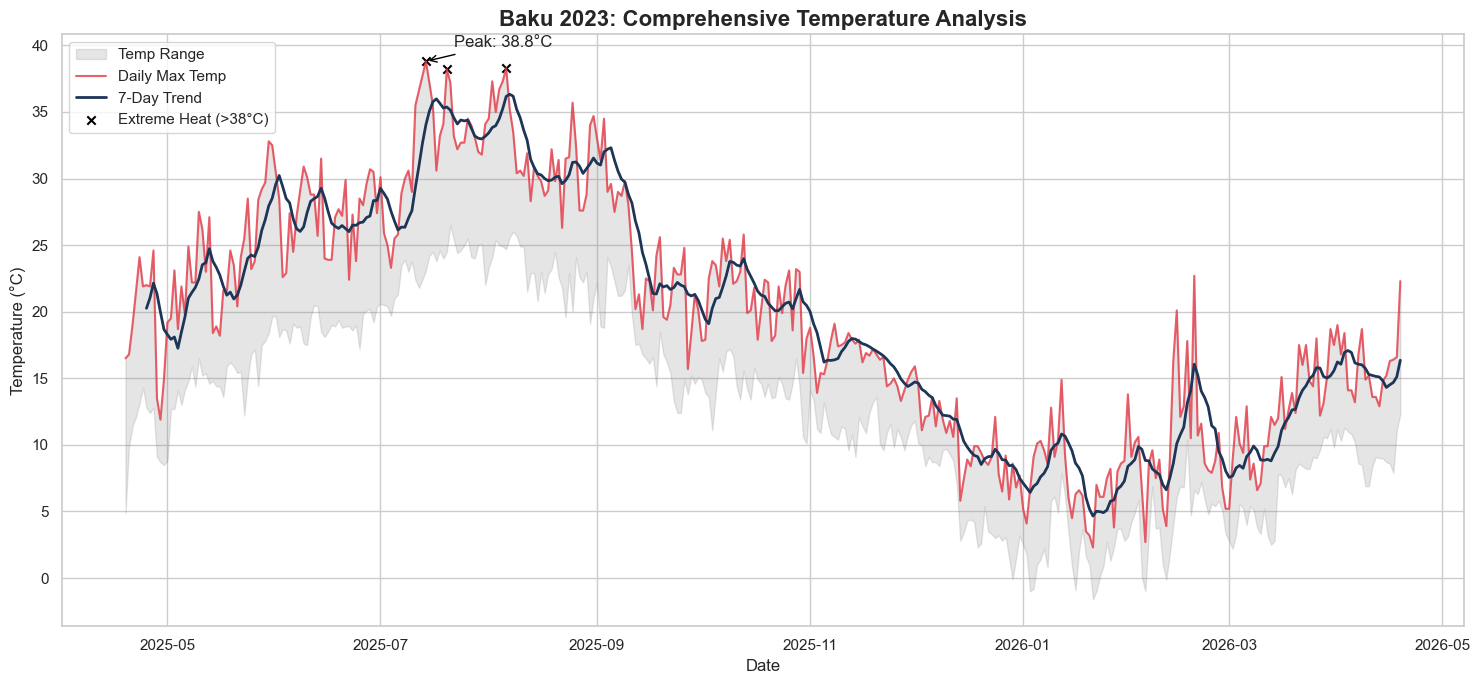

Data Audit for Baku:
- Missing values: 0
- Max recorded temperature: 38.8°C on 2025-07-14


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Daha professional stil seçək
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 7))

# 1. Kölgələmə (Min və Max temperatur arasındakı diapazon)
plt.fill_between(df_baku['time'], df_baku['temperature_2m_min'], 
                 df_baku['temperature_2m_max'], color='gray', alpha=0.2, label='Temp Range')

# 2. Əsas xətt (Maksimum temperatur)
plt.plot(df_baku['time'], df_baku['temperature_2m_max'], 
         color='#e63946', linewidth=1.5, label='Daily Max Temp', alpha=0.8)

# 3. Rolling Mean (7 günlük trend - dalğalanmanı hamarlaşdırır)
df_baku['temp_trend'] = df_baku['temperature_2m_max'].rolling(window=7).mean()
plt.plot(df_baku['time'], df_baku['temp_trend'], 
         color='#1d3557', linewidth=2, label='7-Day Trend')

# 4. Anomaliya yoxlaması: Əgər temperatur 38 dərəcədən çoxdursa, onları qeyd edək
hot_days = df_baku[df_baku['temperature_2m_max'] > 38]
plt.scatter(hot_days['time'], hot_days['temperature_2m_max'], 
            color='black', marker='x', label='Extreme Heat (>38°C)')

# Dizayn detalları
plt.title('Baku 2023: Comprehensive Temperature Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(loc='upper left', frameon=True)

# 5. Qeyd (Annotation)
max_temp = df_baku['temperature_2m_max'].max()
max_date = df_baku.loc[df_baku['temperature_2m_max'].idxmax(), 'time']
plt.annotate(f'Peak: {max_temp}°C', xy=(max_date, max_temp), xytext=(20, 10),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

# Audit:
print(f"Data Audit for Baku:")
print(f"- Missing values: {df_baku['temperature_2m_max'].isnull().sum()}")
print(f"- Max recorded temperature: {max_temp}°C on {max_date.date()}")

In [ ]:
forecast_url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 40.41,
    "longitude": 49.87,
    "daily": [
        "temperature_2m_max",
        "precipitation_sum",        
        "windspeed_10m_max",        
        "relative_humidity_2m_max"  
    ],
    "forecast_days": 7,
    "timezone": "auto"
}

response = requests.get(forecast_url, params=params)
f_data = response.json()

df_forecast = pd.DataFrame(f_data['daily'])

print("--- 7-Day Forecast Structure ---")
print(f_data.keys())
print("\n--- Comparison Analysis ---")
print(f"Structure Keys: {list(f_data.keys())}")

--- 7-Day Forecast Structure ---
dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])

--- Comparison Analysis ---
Structure Keys: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily']


In [ ]:
variable_documentation = {
    "temperature_2m_max": {
        "unit": "°C",
        "description": "Maximum daily air temperature at 2 meters above ground.",
        "relevance": "Primary target for our prediction model."
    },
    "precipitation_sum": {
        "unit": "mm",
        "description": "Sum of daily precipitation (rain, snow, etc.).",
        "relevance": "Important for detecting extreme weather events."
    },
    "wind_speed_10m_max": {
        "unit": "km/h",
        "description": "Maximum wind speed at 10 meters above ground.",
        "relevance": "Critical factor for Baku's climate analysis."
    },
    "relative_humidity_2m_max": {
        "unit": "%",
        "description": "Maximum relative humidity at 2 meters above ground.",
        "relevance": "Influences how the temperature is perceived (Heat Index)."
    }
}

## Task 3 — City & Variable Selection

In [ ]:
import pandas as pd

city_data = [
            # IRAN (Caspian + North)
            {"name": "Rasht", "lat": 37.28, "lon": 49.59, "districts": ["Golsar", "Manzariyeh", "Sabze Meydan"]},
            {"name": "Sari", "lat": 36.56, "lon": 53.06, "districts": ["Imam Square", "Shafa", "Kolaijan"]},
            {"name": "Gorgan", "lat": 36.84, "lon": 54.44, "districts": ["Talaghani", "Enghelab", "Shahid Beheshti"]},
            {"name": "Bandar-e Anzali", "lat": 37.47, "lon": 49.46, "districts": ["Ghazian", "Center", "Pasdaran"]},
            
            # RUSSIA (Dagestan)
            {"name": "Makhachkala", "lat": 42.98, "lon": 47.50, "districts": ["Leninsky", "Sovietsky", "Kirovsky"]},
            {"name": "Derbent", "lat": 42.06, "lon": 48.29, "districts": ["Old City", "Naryn-Kala", "South"]},
            
            # ARMENIA
            {"name": "Yerevan", "lat": 40.17, "lon": 44.51, "districts": ["Kentron", "Arabkir", "Davtashen"]},
            {"name": "Gyumri", "lat": 40.79, "lon": 43.84, "districts": ["Kumayri", "Ani", "Mush"]},
            
            # TURKEY (East Anatolia)
            {"name": "Erzurum", "lat": 39.90, "lon": 41.27, "districts": ["Yakutiye", "Palandoken", "Aziziye"]},
            {"name": "Van", "lat": 38.50, "lon": 43.38, "districts": ["Ipekyolu", "Tusba", "Edremit"]},
            {"name": "Malatya", "lat": 38.35, "lon": 38.31, "districts": ["Battalgazi", "Yesilyurt", "Dogansehir"]},
            
            # GEORGIA
            {"name": "Tbilisi", "lat": 41.71, "lon": 44.78, "districts": ["Vake", "Saburtalo", "Old Tbilisi"]},
            {"name": "Batumi", "lat": 41.65, "lon": 41.64, "districts": ["Old Batumi", "Boulevard", "Gonio"]},
            {"name": "Kutaisi", "lat": 42.27, "lon": 42.70, "districts": ["Center", "Avangardi", "Nikea"]},
            
            # KAZAKHSTAN (West)
            {"name": "Atyrau", "lat": 47.11, "lon": 51.92, "districts": ["Central", "Balykshi", "Zhumysker"]},
            {"name": "Aktau", "lat": 43.65, "lon": 51.16, "districts": ["Microdistrict 1", "Microdistrict 5", "Port Area"]},
            {"name": "Oral", "lat": 51.23, "lon": 51.37, "districts": ["Central", "Zachagansk", "Avtovokzal"]},
            
            # TURKMENISTAN (West)
            {"name": "Turkmenbashi", "lat": 40.05, "lon": 52.99, "districts": ["Avaza", "Port Zone", "Central"]},
            {"name": "Balkanabat", "lat": 39.51, "lon": 54.37, "districts": ["Industrial", "Central", "Nebitdag"]},
            
            # AZERBAIJAN (city + region centers)
            {"name": "Baku", "lat": 40.41, "lon": 49.87, "districts": ["Nesimi", "Yasamal", "Sebail", "Nerimanov", "Xetai"]},
            {"name": "Ganja", "lat": 40.68, "lon": 46.36, "districts": ["Kapaz", "Nizami", "Yeni Gence", "Gulustan"]},
            {"name": "Nakhchivan", "lat": 39.21, "lon": 45.41, "districts": ["Alinja", "Batabat", "Sirab"]},
            {"name": "Sumqayit", "lat": 40.58, "lon": 49.66, "districts": ["1-ci mikrorayon", "2-ci mikrorayon", "Saray", "Corat"]},
            {"name": "Lankaran", "lat": 38.75, "lon": 48.85, "districts": ["Germatuk", "Hirkan", "Girmikhon"]},
            {"name": "Mingachevir", "lat": 40.76, "lon": 47.05, "districts": ["Energetikler", "Guneshli", "Baglar"]},
            {"name": "Naftalan", "lat": 40.51, "lon": 46.82, "districts": ["Merkez", "Qashalti"]},
            {"name": "Khankendi", "lat": 39.82, "lon": 46.75, "districts": ["Center", "Kosalar"]},
            {"name": "Sheki", "lat": 41.19, "lon": 47.17, "districts": ["Kish", "Oxud", "Bas Goynuk"]},
            {"name": "Shirvan", "lat": 39.93, "lon": 48.92, "districts": ["Merkez", "Bayramli"]},
            {"name": "Yevlakh", "lat": 40.62, "lon": 47.15, "districts": ["Aran", "Varvara"]},
            {"name": "Absheron", "lat": 40.49, "lon": 49.75, "districts": ["Xirdalan", "Masazir", "Novkhani"]},
            {"name": "Agjabadi", "lat": 40.05, "lon": 47.46, "districts": ["Hindarkh", "Boyat"]},
            {"name": "Agdam", "lat": 39.99, "lon": 46.93, "districts": ["Quzanli", "Sarijali"]},
            {"name": "Agdash", "lat": 40.65, "lon": 47.47, "districts": ["Leki", "Arabocaqi"]},
            {"name": "Agdere", "lat": 40.21, "lon": 46.81, "districts": ["Talish", "Hasanriz"]},
            {"name": "Agstafa", "lat": 41.12, "lon": 45.45, "districts": ["Poylu", "Dag Kesemen"]},
            {"name": "Agsu", "lat": 40.57, "lon": 48.40, "districts": ["Goylar", "Kalva"]},
            {"name": "Astara", "lat": 38.46, "lon": 48.87, "districts": ["Pensar", "Artupa"]},
            {"name": "Babek", "lat": 39.15, "lon": 45.45, "districts": ["Nehram", "Cehri"]},
            {"name": "Balakan", "lat": 41.73, "lon": 46.41, "districts": ["Katekh", "Gullar"]},
            {"name": "Beylagan", "lat": 39.78, "lon": 47.62, "districts": ["Orencala", "Dunyamalilar"]},
            {"name": "Barda", "lat": 40.37, "lon": 47.13, "districts": ["Nazirli", "Guloglular"]},
            {"name": "Bilesuvar", "lat": 39.46, "lon": 48.55, "districts": ["Amankend", "Dayikend"]},
            {"name": "Jabrayil", "lat": 39.40, "lon": 47.03, "districts": ["Mehdili", "Soltanli"]},
            {"name": "Jalilabad", "lat": 39.21, "lon": 48.49, "districts": ["Goytepe", "Uzuntepe"]},
            {"name": "Julfa", "lat": 38.96, "lon": 45.63, "districts": ["Yayji", "Kyrna"]},
            {"name": "Dashkasan", "lat": 40.52, "lon": 46.08, "districts": ["Bayan", "Zeyva"]},
            {"name": "Fuzuli", "lat": 39.60, "lon": 47.15, "districts": ["Horadiz", "Alxanli"]},
            {"name": "Gadabay", "lat": 40.57, "lon": 45.81, "districts": ["Soyudlu", "Novosaratovka"]},
            {"name": "Goranboy", "lat": 40.61, "lon": 46.79, "districts": ["Safikurd", "Tapqaraqoyunlu"]},
            {"name": "Goychay", "lat": 40.65, "lon": 47.74, "districts": ["Bighir", "Potu"]},
            {"name": "Goygol", "lat": 40.59, "lon": 46.32, "districts": ["Hacikend", "Zurnabad"]},
            {"name": "Hajigabul", "lat": 40.04, "lon": 48.93, "districts": ["Navahi", "Pirsaat"]},
            {"name": "Khachmaz", "lat": 41.46, "lon": 48.80, "districts": ["Nabran", "Khudat"]},
            {"name": "Khizi", "lat": 40.91, "lon": 49.07, "districts": ["Altıaghaj", "Yashma"]},
            {"name": "Khojaly", "lat": 39.91, "lon": 46.79, "districts": ["Ballija", "Seyidbeyli"]},
            {"name": "Khojavend", "lat": 39.79, "lon": 47.00, "districts": ["Hadrut", "Tug"]},
            {"name": "Imishli", "lat": 39.87, "lon": 48.06, "districts": ["Baharli", "Sarixanli"]},
            {"name": "Ismayilli", "lat": 40.78, "lon": 48.15, "districts": ["Lahij", "Basqal"]},
            {"name": "Kalbajar", "lat": 40.10, "lon": 46.04, "districts": ["Vank", "Baslibel"]},
            {"name": "Kangarli", "lat": 39.39, "lon": 45.05, "districts": ["Qivraq", "Shakhtakhti"]},
            {"name": "Kurdamir", "lat": 40.34, "lon": 48.16, "districts": ["Shilyan", "Karrar"]},
            {"name": "Gakh", "lat": 41.42, "lon": 46.92, "districts": ["Ilisu", "Lekit"]},
            {"name": "Gazakh", "lat": 41.09, "lon": 45.37, "districts": ["Dashsalahlı", "Kosalar"]},
            {"name": "Gabala", "lat": 40.98, "lon": 47.84, "districts": ["Vandam", "Nij"]},
            {"name": "Gobustan", "lat": 40.53, "lon": 48.93, "districts": ["Maraza", "Nabur"]},
            {"name": "Guba", "lat": 41.36, "lon": 48.51, "districts": ["Qirmizi Qesebe", "Amsar"]},
            {"name": "Gubadli", "lat": 39.34, "lon": 46.58, "districts": ["Khanlig", "Muradxanli"]},
            {"name": "Gusar", "lat": 41.43, "lon": 48.43, "districts": ["Hazra", "Anig"]},
            {"name": "Lachin", "lat": 39.64, "lon": 46.55, "districts": ["Zabukh", "Sus"]},
            {"name": "Lerik", "lat": 38.77, "lon": 48.42, "districts": ["Zuvand", "Veri"]},
            {"name": "Masalli", "lat": 39.04, "lon": 48.66, "districts": ["Boradigah", "Arkevan"]},
            {"name": "Neftchala", "lat": 39.38, "lon": 49.25, "districts": ["Banke", "Qoltuq"]},
            {"name": "Oghuz", "lat": 41.07, "lon": 47.47, "districts": ["Padar", "Dashagil"]},
            {"name": "Ordubad", "lat": 38.91, "lon": 46.02, "districts": ["Nusnus", "Vənənd"]},
            {"name": "Saatli", "lat": 39.94, "lon": 48.37, "districts": ["Varxan", "Simada"]},
            {"name": "Sabirabad", "lat": 40.01, "lon": 48.47, "districts": ["Surra", "Ulacali"]},
            {"name": "Salyan", "lat": 39.60, "lon": 48.98, "districts": ["Kursengi", "Shorsulu"]},
            {"name": "Samukh", "lat": 40.77, "lon": 46.41, "districts": ["Kolayir", "Qarabaglar"]},
            {"name": "Sadarak", "lat": 39.72, "lon": 44.88, "districts": ["Heydarabad", "Karakend"]},
            {"name": "Siyazan", "lat": 41.08, "lon": 49.11, "districts": ["Zarat", "Beshbarmaq"]},
            {"name": "Shabran", "lat": 41.22, "lon": 48.99, "districts": ["Pirabadil", "Aygunlu"]},
            {"name": "Shahbuz", "lat": 39.40, "lon": 45.57, "districts": ["Badamli", "Kechili"]},
            {"name": "Shamakhi", "lat": 40.63, "lon": 48.64, "districts": ["Madrasa", "Sabir"]},
            {"name": "Shamkir", "lat": 40.83, "lon": 46.02, "districts": ["Chinarly", "Mahmudlu"]},
            {"name": "Sharur", "lat": 39.55, "lon": 44.98, "districts": ["Arabyengija", "Yengija"]},
            {"name": "Shusha", "lat": 39.76, "lon": 46.75, "districts": ["Dashalti", "Turshsu"]},
            {"name": "Tartar", "lat": 40.34, "lon": 46.93, "districts": ["Seydimli", "Sarov"]},
            {"name": "Tovuz", "lat": 40.99, "lon": 45.63, "districts": ["Dondar Gushchu", "Oysuzlu"]},
            {"name": "Ujar", "lat": 40.52, "lon": 47.65, "districts": ["Qazyan", "Kuchukend"]},
            {"name": "Yardimli", "lat": 38.91, "lon": 48.24, "districts": ["Demirchi", "Arvana"]},
            {"name": "Zagatala", "lat": 41.63, "lon": 46.64, "districts": ["Aliabad", "Mosul"]},
            {"name": "Zangilan", "lat": 39.08, "lon": 46.65, "districts": ["Aghband", "Minjivan"]},
            {"name": "Zardab", "lat": 40.22, "lon": 47.71, "districts": ["Goradiz", "Maliklu"]}
        ]


df_cities = pd.DataFrame(city_data)
print(df_cities.head())

         City  Latitude  Longitude              Why this city?  5.4000
0        Baku   40.4100    49.8700  Home city, local relevance     NaN
1       Ganja   40.6850    46.3500     Major industrial center     NaN
2  Nakhchivan   39.2092    45.4122  Unique continental climate     NaN
3    Sumqayit   40.5800    49.6300      Coastal industrial hub     NaN
4    Lankaran   38.7540    48.8511   Subtropical high rainfall     NaN
